# Integral ved triangulering

I denne filen skal vi se på hvordan vi deler opp et område i triangler for så å evaluere funksjonen i hvert triangel. 

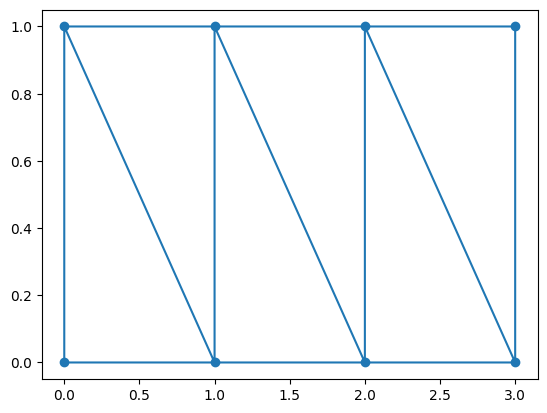

In [2]:
from matplotlib import pyplot as plt
import numpy as np

pts = np.array([[0,0],[0,1],[1,0],[1,1],[2,0],[2,1],[3,0],[3,1]]) #Liste av punkter i planet
triangles = np.array([[0,1,2], [1,2,3], [2,3,4], [3,4,5], [4,5,6], [5,6,7]]) #Dette definerer hvilke punkter I LISTEN PTS som er valgt ut til å danne trekanter

plt.triplot(pts[:,0], pts[:,1], triangles) # Tegner trekanter
plt.scatter(pts[:,0], pts[:,1]) #Plotter punktene som små markører
plt.show()

4.666666666666666
[[0.33333333 0.33333333]
 [0.66666667 0.66666667]
 [1.33333333 0.33333333]
 [1.66666667 0.66666667]
 [2.33333333 0.33333333]
 [2.66666667 0.66666667]]
[0.5 0.5 0.5 0.5 0.5 0.5]


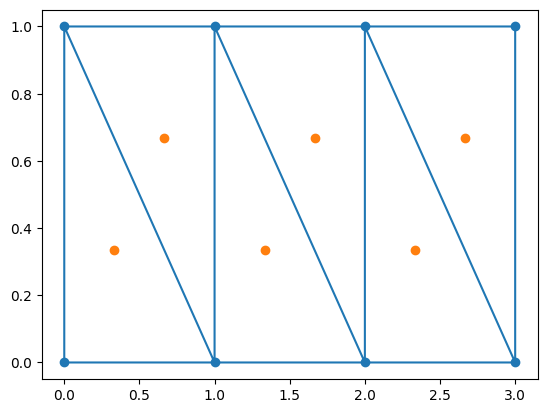

In [3]:
import numpy as np
from matplotlib import pyplot as plt

pts = np.array([[0,0],[0,1],[1,0],[1,1],[2,0],[2,1],[3,0],[3,1]])
triangles = np.array([[0,1,2], [1,2,3], [2,3,4], [3,4,5], [4,5,6], [5,6,7]]) #Lager trekanter med å angi hvilke punkter i listen pts som er hjørner i trekanten

p = pts[triangles[:,0]] #Lager en array med første hjørne i trekantene
q = pts[triangles[:,1]] #Lager en array med andre hjørne i trekantene
r = pts[triangles[:,2]] ##Lager en array med tredje hjørne i trekantene
n = len(p) #Trengs senere

avg = 1/3 * (p + q + r) # Definerer tyngdepunktet
x = avg[:,0]
y = avg[:,1]
f = x**2*y #Definerer funksjonen f som skal evalueres i punktet x,y.

#Plotting
plt.triplot(pts[:,0], pts[:,1], triangles) # Tegner trekanter
plt.scatter(pts[:,0], pts[:,1]) #Plotter punktene som små markører
plt.scatter(x,y) #Plotter average (altså massesenter)


#Lager vektorer som spenner ut trekantene
u = q - p 
v = r - p

#Sette sammen vektorene u og v som kolonner i en 2by2-matrise:
Muv = np.column_stack((u,v)).reshape(n,2,2) #Her lages en array av matriser (en 3D numpy-array).
dA = np.abs(1/2*np.linalg.det(Muv)) # Regner ut arealet dA av hver trekant ved å bruke determinanten



svar = np.sum(dA*f)
print(svar)
print(avg)
print(dA)

# Bruke Python (Delanay) til å generere trekanter

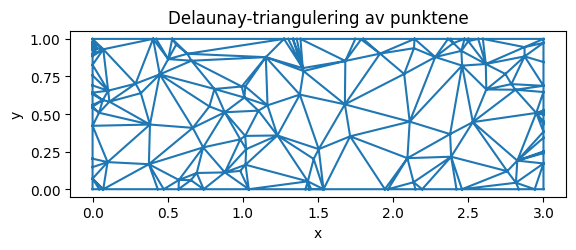

4.489985679361643


In [13]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.spatial import Delaunay               

# ------------------------------------------------------------
# 1) Lag punkter i området og sørg for gode randpunkter
# ------------------------------------------------------------

pts = np.random.rand(150,2)       # 150 tilfeldige (x,y) i enhetsskvadratet [0,1]×[0,1]
pts[:,0] *= 3.0                   # strekk x-koordinaten → punkter i [0,3]×[0,1]

# Fest de fire hjørnene eksplisitt, slik at trianguleringen dekker hele [0,3]×[0,1]
pts[0] = [0,0]                    # hjørne (venstre-nede)
pts[1] = [3,0]                    # hjørne (høyre-nede)
pts[2] = [0,1]                    # hjørne (venstre-oppe)
pts[3] = [3,1]                    # hjørne (høyre-oppe)

# Plasser en del ekstra punkter på randene for å få et penere/mer stabilt nett langs kanten.
# (Indeksintervallene er vilkårlige – de fyller ut hver kant med flere punkter.)
pts[4:20,0]  = 3.0                # punkt på høyre kant (x=3)
pts[21:40,0] = 0.0                # punkt på venstre kant (x=0)
pts[41:60,1] = 1.0                # punkt på øvre kant (y=1)
pts[61:80,1] = 0.0                # punkt på nedre kant (y=0)

# Delaunay-triangulering av punktene – gir et trekantnett som dekker konvekse hylsteret
tri = Delaunay(pts)

# Visualiser trekantnettet (tri.simplices er indeks-treklene som definerer hver trekant)
plt.triplot(pts[:,0], pts[:,1], tri.simplices)
plt.gca().set_aspect("equal", adjustable="box")
plt.title("Delaunay-triangulering av punktene")
plt.xlabel("x"); plt.ylabel("y")
plt.show()

# ------------------------------------------------------------
# 2) Forbered integrasjon over trianguleringen
#    – midtpunkts-/tyngdepunktsregel per trekant
# ------------------------------------------------------------

# Hent ut hjørnepunkt for hver trekant:
p = pts[tri.simplices[:,0]]       # (n,2) – første hjørne i hver trekant
q = pts[tri.simplices[:,1]]       # (n,2) – andre hjørne
r = pts[tri.simplices[:,2]]       # (n,2) – tredje hjørne
n = len(p)                        # antall trekanter

# Tyngdepunkt (centroid) i hver trekant: C = (p+q+r)/3
avg = 1/3 * (p + q + r)           # (n,2)
x = avg[:,0]
y = avg[:,1]

# Funksjonen vi vil integrere: f(x,y) = x^2 * y, evaluert i trekantens tyngdepunkt
f = x*x*y                         # (n,)

# ------------------------------------------------------------
# 3) Beregn areal for hver trekant
#    – areal = 1/2 * |det([u v])|, der u=q-p og v=r-p
# ------------------------------------------------------------

u = q - p                         # (n,2) – sidevektor 1
v = r - p                         # (n,2) – sidevektor 2

# Lag en 2×2-matrise [u v] for hver trekant og ta determinanten
Muv = np.column_stack((u, v)).reshape(n, 2, 2)   # (n,2,2)
dA = np.abs(0.5 * np.linalg.det(Muv))            # (n,) – trekant-areal

# ------------------------------------------------------------
# 4) Riemann-sum ≈ flateintegral over området
#    Integral ≈ sum (areal_trekant * f(centroid_trekant))
# ------------------------------------------------------------

svar = np.sum(dA * f)
print(svar)

# Merk:
# - Dette er midtpunktsregelen på hver trekant, så resultatet er en numerisk approksimasjon
#   av ∫∫_Ω x^2 y dA over området Ω ≈ konvekse hylsteret til punktene (i praksis ~ [0,3]×[0,1]).
# - For den eksakte rektangelen [0,3]×[0,1] er integralet analytisk:
#     ∫_0^3 ∫_0^1 x^2 y dy dx = (∫_0^3 x^2 dx) * (∫_0^1 y dy) = (9) * (1/2) = 4.5
#   Med mange/jevnere trekanter bør "svar" ligge nær ~4.5.

## 3 dim: Å bruke Delanay for å beregne volum av tetrahedron

Exact volume: 50.26548245743669
Total number of points: 5312
Number of tetrahedra: 37994

Estimated volume (Delaunay): 50.262102
Exact volume (πR²H):         50.265482
Absolute error:              -0.003381
Relative error:              -0.0067 %
Within ±0.1 tolerance?  -> True


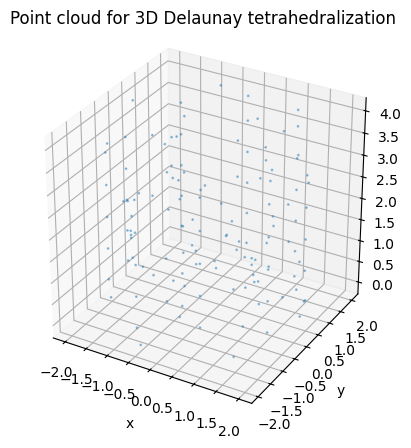

In [22]:
# ============================================================
# NUMERICAL ESTIMATION OF THE VOLUME OF A CYLINDER USING
# 3D DELAUNAY TETRAHEDRALIZATION
#
# Cylinder: radius R = 2, height H = 4
# Analytical volume = π * R^2 * H = 16π ≈ 50.265
# ============================================================

import numpy as np
from scipy.spatial import Delaunay
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ============================================================
# 1) Set up geometry and exact reference volume
# ============================================================

np.random.seed(7)  # reproducibility

R = 2.0     # radius
H = 4.0     # height
V_exact = np.pi * R**2 * H   # analytical volume
print("Exact volume:", V_exact)

# ============================================================
# 2) Helper functions to generate points in/on the cylinder
# ============================================================

def sample_disk_boundary(radius, z, n_theta):
    """
    n_theta points evenly spaced on the circle (x,y) of given radius
    at height z. Returns (n_theta, 3).
    """
    theta = np.linspace(0, 2*np.pi, n_theta, endpoint=False)
    x = radius * np.cos(theta)
    y = radius * np.sin(theta)
    z = np.full_like(x, fill_value=z, dtype=float)
    return np.column_stack([x, y, z])

def sample_cylinder_side(radius, z_values, n_theta):
    """
    Points on the cylindrical side surface.
    For each z in z_values, n_theta points around the circle.
    Returns (len(z_values)*n_theta, 3).
    """
    pts_list = []
    theta = np.linspace(0, 2*np.pi, n_theta, endpoint=False)
    cos_t, sin_t = np.cos(theta), np.sin(theta)
    for z in z_values:
        x = radius * cos_t
        y = radius * sin_t
        zc = np.full_like(x, z, dtype=float)
        pts_list.append(np.column_stack([x, y, zc]))
    return np.vstack(pts_list)

def sample_cylinder_interior(radius, h, n_points):
    """
    Uniform random sampling inside the cylinder volume.
    r ~ R*sqrt(U) ensures uniform density over the disk.
    Returns (n_points, 3).
    """
    theta = np.random.rand(n_points) * 2*np.pi
    r = radius * np.sqrt(np.random.rand(n_points))
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    z = np.random.rand(n_points) * h
    return np.column_stack([x, y, z])

# ============================================================
# 3) Generate the point cloud for Delaunay triangulation
# ============================================================

N_RING_TOP_BOTTOM = 256    # points on top/bottom circles
N_SIDE_LEVELS = 10         # intermediate z-levels on side surface
z_side = np.linspace(0, H, N_SIDE_LEVELS+2)[1:-1]  # exclude 0 and H
N_THETA_SIDE = 180         # points around circumference for side rings
N_INTERIOR = 3000          # interior random points

top = sample_disk_boundary(R, z=H, n_theta=N_RING_TOP_BOTTOM)
bottom = sample_disk_boundary(R, z=0.0, n_theta=N_RING_TOP_BOTTOM)
side = sample_cylinder_side(R, z_side, n_theta=N_THETA_SIDE)
interior = sample_cylinder_interior(R, H, N_INTERIOR)

pts = np.vstack([top, bottom, side, interior])
print("Total number of points:", len(pts))

# ============================================================
# 4) 3D Delaunay tetrahedralization
# ============================================================

tri = Delaunay(pts, qhull_options="QJ")  # 'QJ' perturbs slightly to avoid degeneracy
simp = tri.simplices   # shape (m, 4) – indices of 4 vertices per tetrahedron
print("Number of tetrahedra:", len(simp))

# ============================================================
# 5) Compute tetrahedron volumes and total volume
# ============================================================

T = pts[simp]               # (m, 4, 3)
p = T[:, 0, :]              # (m, 3)
u = T[:, 1, :] - p          # (m, 3)
v = T[:, 2, :] - p          # (m, 3)
w = T[:, 3, :] - p          # (m, 3)

# Volume(T) = | (u × v) · w | / 6
cross_uv = np.cross(u, v)   # (m, 3)
vol_tetra = np.abs(np.einsum('ij,ij->i', cross_uv, w)) / 6.0
V_est = np.sum(vol_tetra)

# ============================================================
# 6) Compare with analytical value
# ============================================================

err = V_est - V_exact
rel_err = err / V_exact

print(f"\nEstimated volume (Delaunay): {V_est:.6f}")
print(f"Exact volume (πR²H):         {V_exact:.6f}")
print(f"Absolute error:              {err:.6f}")
print(f"Relative error:              {100*rel_err:.4f} %")
print("Within ±0.1 tolerance?  ->", np.abs(err) <= 0.1)

# ============================================================
# 7) Optional: visualize the point cloud in 3D
# ============================================================

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pts[::40,0], pts[::40,1], pts[::40,2], s=1, alpha=0.4)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Point cloud for 3D Delaunay tetrahedralization')
ax.set_box_aspect((1,1,H/(2*R)))
plt.show()